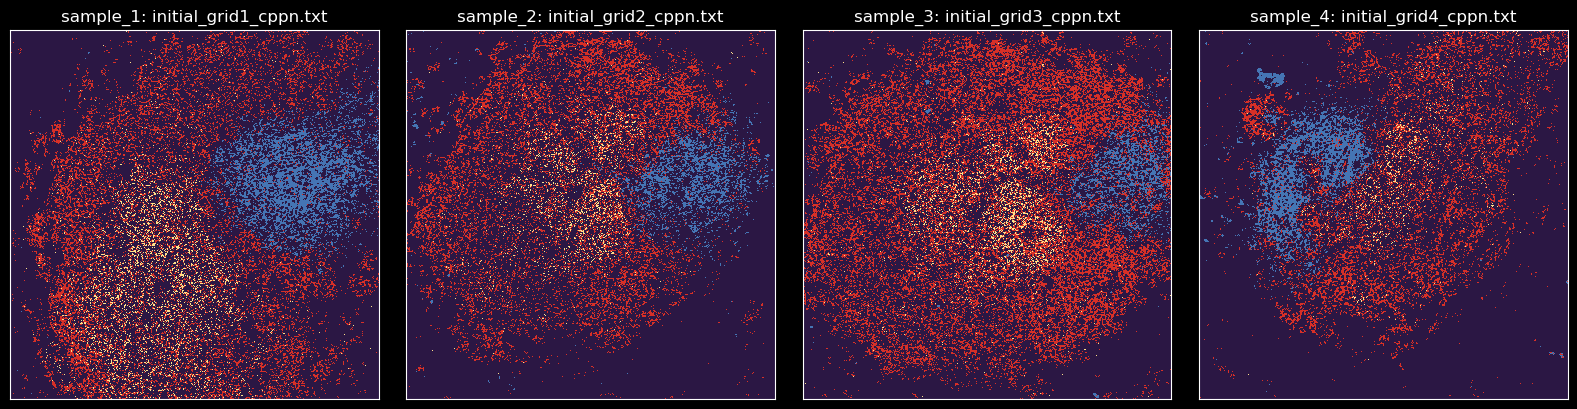

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rootutils
from matplotlib.colors import ListedColormap

rootutils.setup_root(Path.cwd(), indicator=".project-root", pythonpath=True)
PROJECT_ROOT = Path(rootutils.find_root(Path.cwd(), indicator=".project-root"))
DATA_DIR = PROJECT_ROOT / "data" / "spatial2D"

color_map = {
    "red": [90, 15, 10],
    "yellow": [120, 120, 10],
    "blue": [10, 10, 90],
    "no_color": [0, 0, 0],
    "green": [10, 120, 10],
    "hotspot": [0, 255, 0],
}
# STATE_CMAP = ListedColormap([
#     np.array(color_map["red"]) / 255,
#     np.array(color_map["yellow"]) / 255,
#     np.array(color_map["blue"]) / 255,
#     np.array(color_map["no_color"]) / 255,
#     np.array(color_map["green"]) / 255,
#     np.array(color_map["hotspot"]) / 255,
# ])
STATE_CMAP = ListedColormap([
    "#d73027",
    "#fee08b",
    "#4575b4",
    "#2b1744",
    "#1a9850",
    "#d9d9d9",
])


def draw_grid(ax, grid, title):
    ax.imshow(grid, cmap=STATE_CMAP, vmin=0, vmax=5, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])


initial_grid_paths = sorted(DATA_DIR.glob("initial_grid*_cppn.txt"))
initial_grids = {path.stem.replace("initial_grid", "sample_").replace("_cppn", ""): np.loadtxt(path, dtype=np.uint8) for path in initial_grid_paths}

fig, axes = plt.subplots(1, len(initial_grid_paths), figsize=(4 * len(initial_grid_paths), 4), squeeze=False)
for ax, path in zip(axes[0], initial_grid_paths):
    sample_id = path.stem.replace("initial_grid", "sample_").replace("_cppn", "")
    draw_grid(ax, initial_grids[sample_id], f"{sample_id}: {path.name}")
fig.tight_layout()
plt.show()


In [2]:
POSTERIOR_MODE_ROOT = Path(
    "/insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/"
    "2026-06-03_11-34-14_bs10_acc2_nw2/posterior_mode"
)


def find_completed_posterior_mode_result(root):
    root = Path(root)
    if not root.exists():
        return None

    candidates = []
    for done_path in root.rglob("DONE"):
        result_path = done_path.parent / "posterior_mode_results.npz"
        if result_path.exists():
            candidates.append(result_path)

    if not candidates:
        return None
    return max(candidates, key=lambda path: path.stat().st_mtime)


RESULTS_NPZ_PATH = find_completed_posterior_mode_result(POSTERIOR_MODE_ROOT)
if RESULTS_NPZ_PATH is None:
    raise FileNotFoundError(
        "No completed posterior mode result found. Submit the HPC job first with:\n"
        "  bash scripts/submit_spatial2D_posterior_mode.sh\n"
        f"Searched under: {POSTERIOR_MODE_ROOT}"
    )

loaded = np.load(RESULTS_NPZ_PATH, allow_pickle=True)
results = []
for idx, sample_id in enumerate(loaded["sample_ids"].tolist()):
    results.append({
        "sample_id": str(sample_id),
        "initial_grid": loaded["initial_grids"][idx],
        "observed_grid": loaded["observed_grids"][idx],
        "simulated_result": loaded["simulated_results"][idx],
    })

print(f"Loaded completed posterior mode result: {RESULTS_NPZ_PATH}")


Loaded completed posterior mode result: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-06-03_11-34-14_bs10_acc2_nw2/posterior_mode/job_submit_2026-06-12_01-50-43/posterior_mode_results.npz


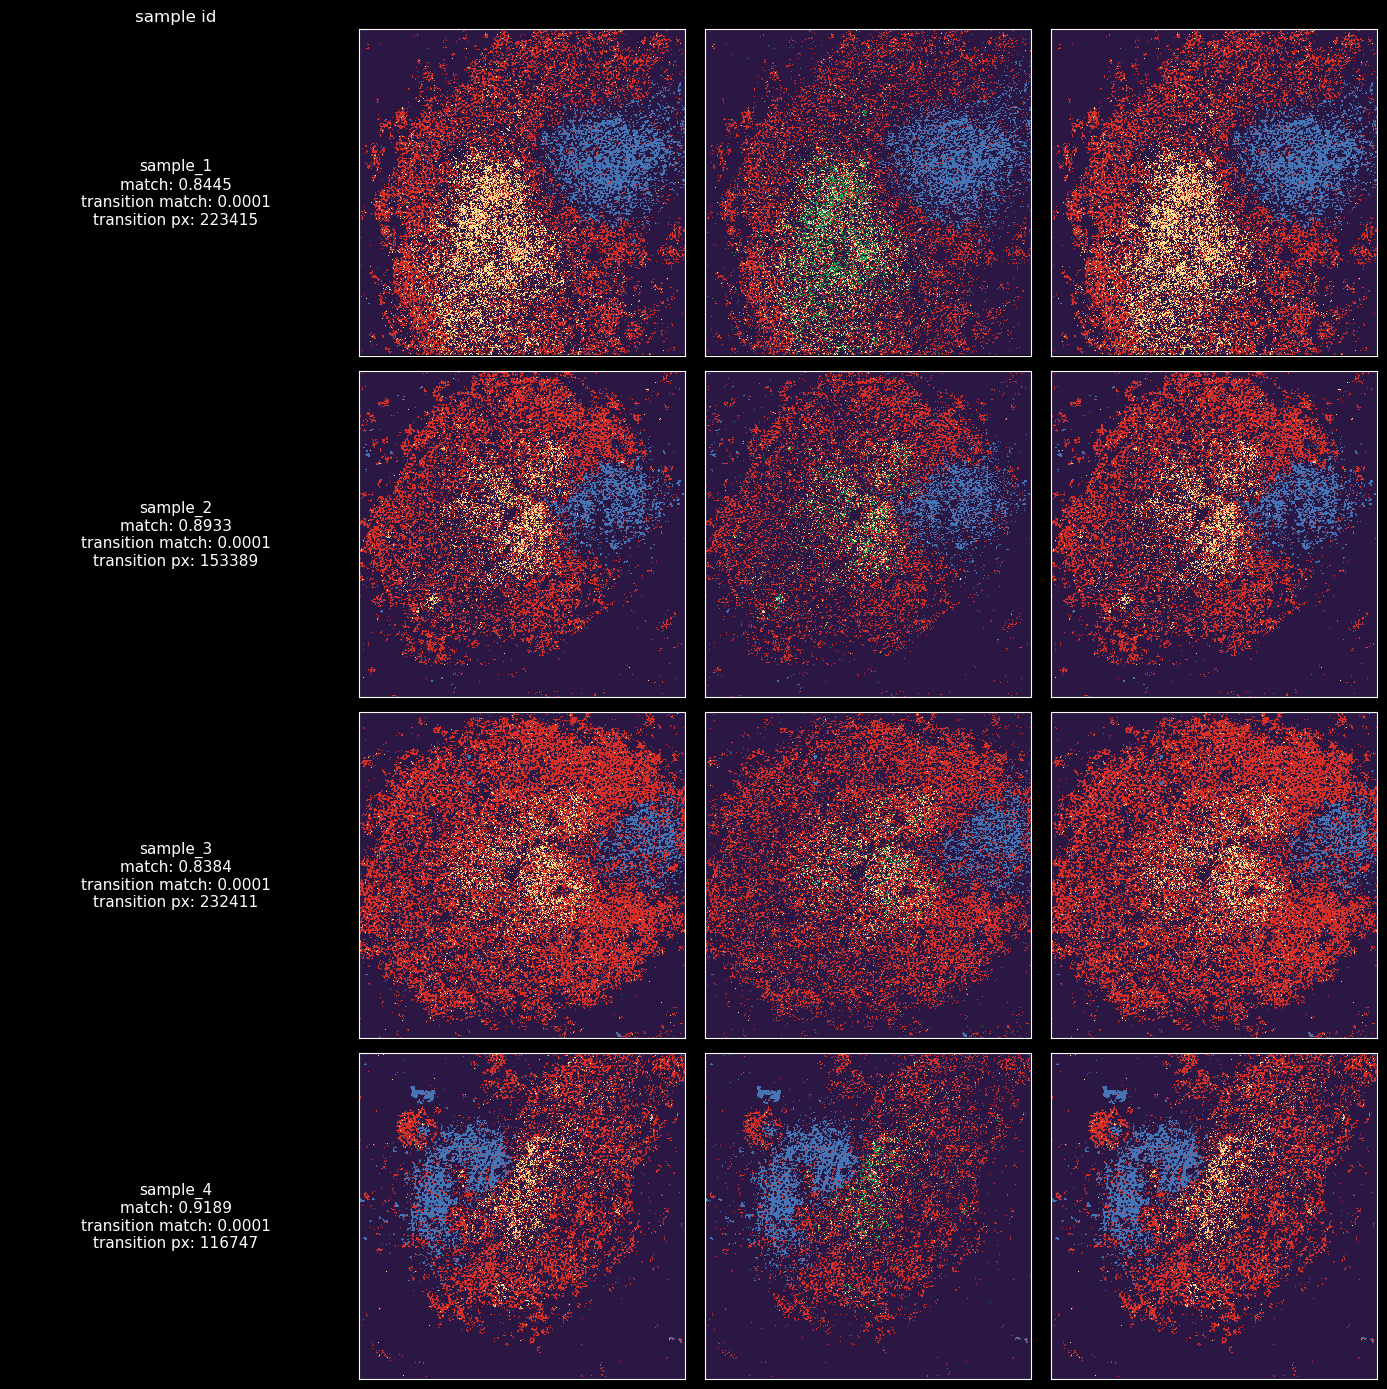

In [3]:
def matching_rate(observed, simulated, mask=None):
    observed = np.asarray(observed)
    simulated = np.asarray(simulated)
    if mask is None:
        mask = np.ones(observed.shape, dtype=bool)
    else:
        mask = np.asarray(mask, dtype=bool)
    if mask.sum() == 0:
        return np.nan
    return float((observed[mask] == simulated[mask]).mean())


for result in results:
    transition_mask = result["initial_grid"] != result["observed_grid"]
    result["matching_rate"] = matching_rate(result["observed_grid"], result["simulated_result"])
    result["transition_matching_rate"] = matching_rate(
        result["observed_grid"],
        result["simulated_result"],
        transition_mask,
    )
    result["transition_pixels"] = int(transition_mask.sum())


fig, axes = plt.subplots(len(results), 4, figsize=(14, 3.5 * len(results)), squeeze=False)
column_titles = ["sample id", "initial grid", "img_to_grid(raw observed final png)", "simulated result"]

for ax, title in zip(axes[0], column_titles):
    ax.set_title(title)

for row_axes, result in zip(axes, results):
    label = (
        f"{result['sample_id']}\n"
        f"match: {result['matching_rate']:.4f}\n"
        f"transition match: {result['transition_matching_rate']:.4f}\n"
        f"transition px: {result['transition_pixels']}"
    )
    row_axes[0].text(0.5, 0.5, label, ha="center", va="center", fontsize=11)
    row_axes[0].set_axis_off()
    draw_grid(row_axes[1], result["initial_grid"], "")
    draw_grid(row_axes[2], result["observed_grid"], "")
    draw_grid(row_axes[3], result["simulated_result"], "")

fig.tight_layout()
plt.show()
